## Data Profiling

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving SuperStore - data.csv to SuperStore - data.csv


In [ ]:
df = pd.read_csv('SuperStore - data.csv')
display(df.head())

,Order_ID,Customer_ID,Postal_Code,Product_ID,Sales,Quantity,Discount,Profit,Category,Sub-Category,Product_Name,Order_Date,Ship_Date,Ship_Mode,Customer_Name,Segment,Country/Region,City,State,Region
0,CA-2019-152156,CG-12520,42420,FUR-BO-10001798,261.9600,2,0.00,41.9136,Furniture,Bookcases,Bush Somerset Collection Bookcase,11/8/2019,11/11/2019,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
1,CA-2019-152156,CG-12520,42420,FUR-CH-10000454,731.9400,3,0.00,219.5820,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",11/8/2019,11/11/2019,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
2,CA-2019-138688,DV-13045,90036,OFF-LA-10000240,14.6200,2,0.00,6.8714,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,6/12/2019,6/16/2019,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,West
3,US-2018-108966,SO-20335,33311,FUR-TA-10000577,957.5775,5,0.45,-383.0310,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,10/11/2018,10/18/2018,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South
4,US-2018-108966,SO-20335,33311,OFF-ST-10000760,22.3680,2,0.20,2.5164,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,10/11/2018,10/18/2018,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        9994 non-null   object 
 1   Customer_ID     9994 non-null   object 
 2   Postal_Code     9994 non-null   int64  
 3   Product_ID      9994 non-null   object 
 4   Sales           9994 non-null   float64
 5   Quantity        9994 non-null   int64  
 6   Discount        9994 non-null   float64
 7   Profit          9994 non-null   float64
 8   Category        9994 non-null   object 
 9   Sub-Category    9994 non-null   object 
 10  Product_Name    9994 non-null   object 
 11  Order_Date      9994 non-null   object 
 12  Ship_Date       9994 non-null   object 
 13  Ship_Mode       9994 non-null   object 
 14  Customer_Name   9994 non-null   object 
 15  Segment         9994 non-null   object 
 16  Country/Region  9994 non-null   object 
 17  City            9994 non-null   o

In [ ]:
df.isna().sum()

,0
Order_ID,0
Customer_ID,0
Postal_Code,0
Product_ID,0
Sales,0
Quantity,0
Discount,0
Profit,0
Category,0
Sub-Category,0


## Summary data dengan pivot_table

In [ ]:
df_product_sales_profit = pd.pivot_table(
    data=df,
    index='Product_Name',
    values=['Sales', 'Profit'],
    aggfunc='sum'
)
display(df_product_sales_profit)

,Profit,Sales
Product_Name,,
"""While you Were Out"" Message Book, One Form per Page",10.3880,25.228
"#10 Gummed Flap White Envelopes, 100/Box",16.7678,41.300
#10 Self-Seal White Envelopes,52.1230,108.682
"#10 White Business Envelopes,4 1/8 x 9 1/2",223.1408,488.904
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",115.2806,286.672
...,...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",115.6440,477.660
iOttie HLCRIO102 Car Mount,-11.9940,215.892
iOttie XL Car Mount,-50.3748,223.888


In [ ]:
print('Styled Head of Product Sales and Profit:')
display(df_product_sales_profit.head().style.background_gradient(cmap='Blues'))

Styled Head of Product Sales and Profit:


,Profit,Sales
Product_Name,,
"""While you Were Out"" Message Book, One Form per Page",10.388000,25.228000
"#10 Gummed Flap White Envelopes, 100/Box",16.767800,41.300000
#10 Self-Seal White Envelopes,52.123000,108.682000
"#10 White Business Envelopes,4 1/8 x 9 1/2",223.140800,488.904000
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",115.280600,286.672000


In [ ]:
print('\nStyled Tail of Product Sales and Profit (Sales blue, Profit redder for lower values):')
display(df_product_sales_profit.tail().style.background_gradient(cmap='Blues', subset=['Sales']).background_gradient(cmap='Reds_r', subset=['Profit']))


Styled Tail of Product Sales and Profit (Sales blue, Profit redder for lower values):


,Profit,Sales
Product_Name,,
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",115.644000,477.660000
iOttie HLCRIO102 Car Mount,-11.994000,215.892000
iOttie XL Car Mount,-50.374800,223.888000
invisibleSHIELD by ZAGG Smudge-Free Screen Protector,171.264800,442.554000
netTALK DUO VoIP Telephone Service,430.418000,1112.788000


* Hipotesis/Asumsi:
1. Terdapat barang yang memiliki profit minus meskipun sales besar

In [ ]:
df_pivot = pd.pivot_table(
    data = df,
    index ='Category',
    values=['Sales', 'Profit'],
    aggfunc=['sum','mean'])

df_pivot

sum                    mean            
                      Profit        Sales     Profit       Sales
Category                                                        
Furniture         18451.2728  741999.7953   8.699327  349.834887
Office Supplies  122490.8008  719047.0320  20.327050  119.324101
Technology       145454.9481  836154.0330  78.752002  452.709276

* Hipotesis/Asumsi:
2. Furniture memiliki profit terendah meskipun memiliki sales yang besar

In [ ]:
df_pivot_region = pd.pivot_table(
    data=df,
    index='Category',
    columns='Region',
    values='Profit',
    aggfunc='sum'
)

<Axes: ylabel='Category'>

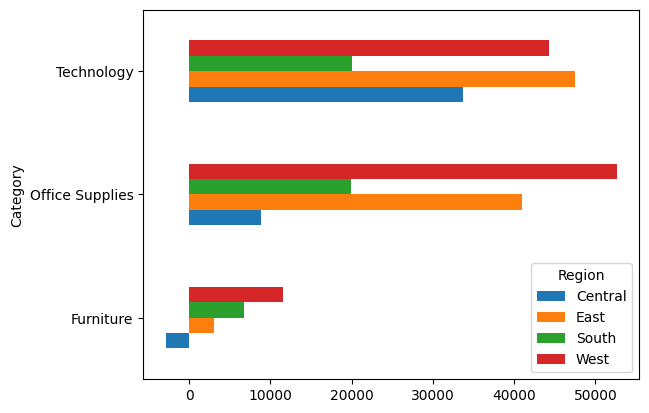

In [ ]:
df_pivot_region.plot(kind='barh')

## Line

In [ ]:
### Total Sales based on Order Date dari waktu ke waktu >>> Trend Penjualan
usecol = ['Order_Date','Sales','Category','Product_Name']
df[usecol]

,Order_Date,Sales,Category,Product_Name
0,11/8/2019,261.9600,Furniture,Bush Somerset Collection Bookcase
1,11/8/2019,731.9400,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,6/12/2019,14.6200,Office Supplies,Self-Adhesive Address Labels for Typewriters b...
3,10/11/2018,957.5775,Furniture,Bretford CR4500 Series Slim Rectangular Table
4,10/11/2018,22.3680,Office Supplies,Eldon Fold 'N Roll Cart System
...,...,...,...,...
9989,1/21/2017,25.2480,Furniture,Ultra Door Pull Handle
9990,2/26/2020,91.9600,Furniture,Tenex B1-RE Series Chair Mats for Low Pile Car...
9991,2/26/2020,258.5760,Technology,Aastra 57i VoIP phone
9992,2/26/2020,29.6000,Office Supplies,"It's Hot Message Books with Stickers, 2 3/4"" x 5"""


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data_year_month = pd.pivot_table(
    data=df,
    index=['Order_Date'],
    values='Profit',
    aggfunc='sum'
).reset_index()


data_year_month

,Order_Date,Profit
0,1/1/2020,-181.4109
1,1/10/2017,22.6537
2,1/10/2018,-373.3048
3,1/10/2019,55.3653
4,1/11/2017,3.0814
...,...,...
1231,9/8/2019,-375.6300
1232,9/8/2020,-510.9671
1233,9/9/2017,16.3616
1234,9/9/2019,12.1616


In [ ]:
# Multiple line

data = pd.pivot_table(
    data=df,
    index=['Order_Date','Category'],
    values=['Sales','Profit'],
    aggfunc='sum'
).reset_index()

data

,Order_Date,Category,Profit,Sales
0,1/1/2020,Furniture,-6.1993,975.490
1,1/1/2020,Office Supplies,-175.2116,506.338
2,1/10/2017,Furniture,21.2954,51.940
3,1/10/2017,Office Supplies,1.3583,2.890
4,1/10/2018,Furniture,-373.3048,1018.104
...,...,...,...,...
2855,9/9/2019,Furniture,-12.0064,15.008
2856,9/9/2019,Office Supplies,24.1680,69.984
2857,9/9/2020,Furniture,-66.8626,482.564
2858,9/9/2020,Office Supplies,155.7536,1427.003


## Scatterplot

<Axes: xlabel='Sales', ylabel='Profit'>

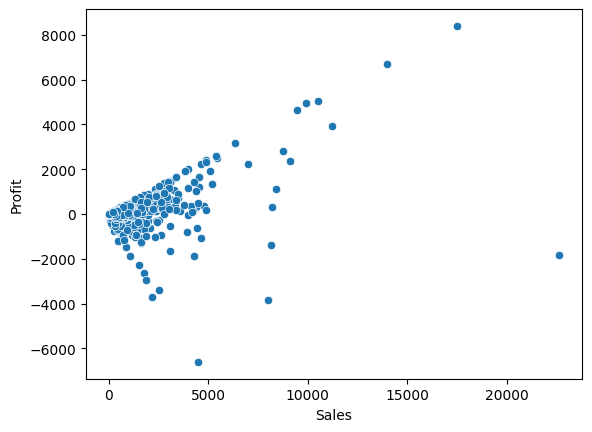

In [ ]:
sns.scatterplot(data=df,
                x='Sales',
                y='Profit')

<Axes: xlabel='Sales', ylabel='Profit'>

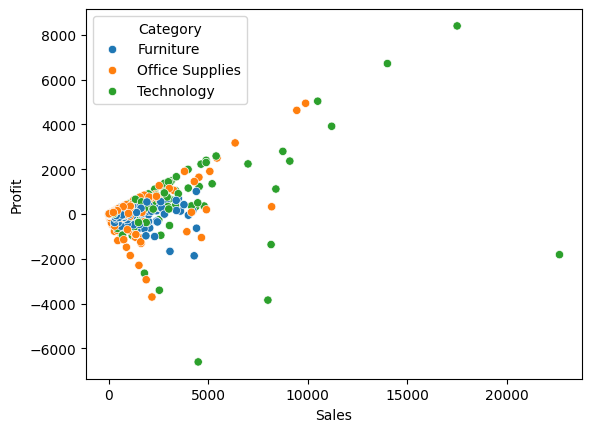

In [ ]:
sns.scatterplot(data=df, x='Sales',
                y='Profit',
                hue='Category')

<Axes: xlabel='Sales', ylabel='Profit'>

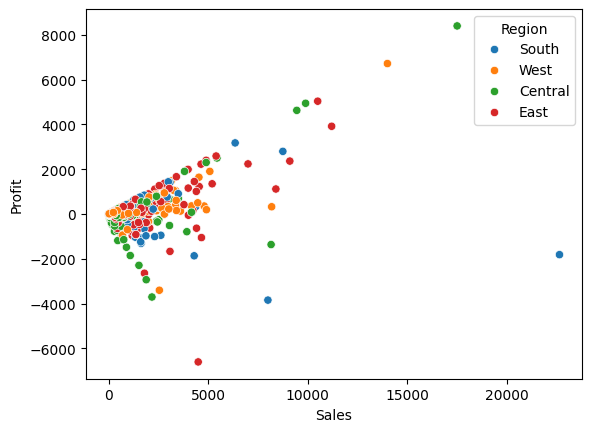

In [ ]:
sns.scatterplot(data=df, x='Sales',
                y='Profit',
                hue='Region')

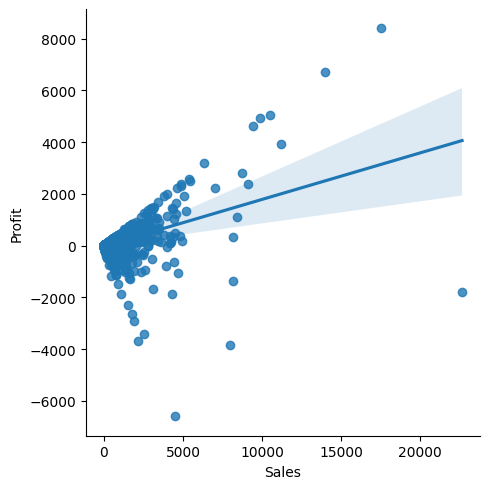

In [ ]:
sns.lmplot(data=df,
            x='Sales',
            y='Profit')

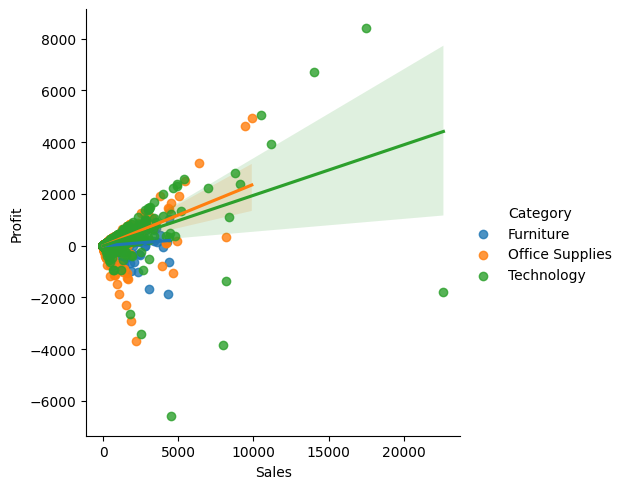

In [ ]:
sns.lmplot(data=df,
            x='Sales',
            y='Profit',
            hue='Category',)

## Distplot

<Axes: xlabel='Sales', ylabel='Count'>

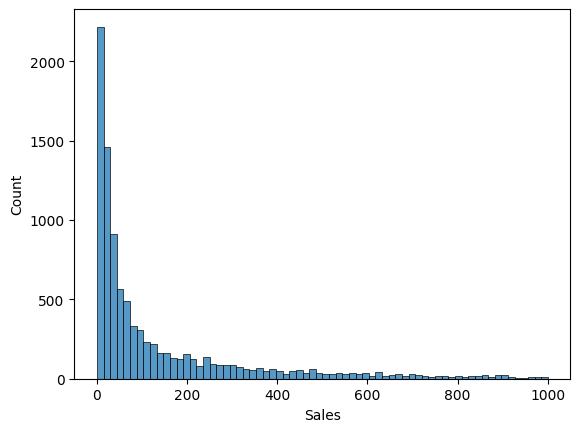

In [ ]:
sns.histplot(df[df['Sales'] < 1000]['Sales'])